In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import math
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
# parameters
IMG_SIZE = 32        # CIFAR-10 image resolution
PATCH_SIZE = 4         # Each patch is 4×4 pixels
IN_CHANNELS = 3         # RGB images
NUM_CLASSES = 10        # 10 CIFAR-10 classes
EMBED_DIM = 512       # Token/embedding dimension
NUM_HEADS = 8         # Multi-head attention heads
DEPTH = 6         # Number of Transformer encoder blocks
MLP_DIM = 256       # Inner dim of the MLP block
DROPOUT = 0.1
BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616]),
])

train_dataset=torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,num_workers=2, pin_memory=True)

CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

#print(f'Train samples: {len(train_dataset):,} | Test samples: {len(test_dataset):,}')

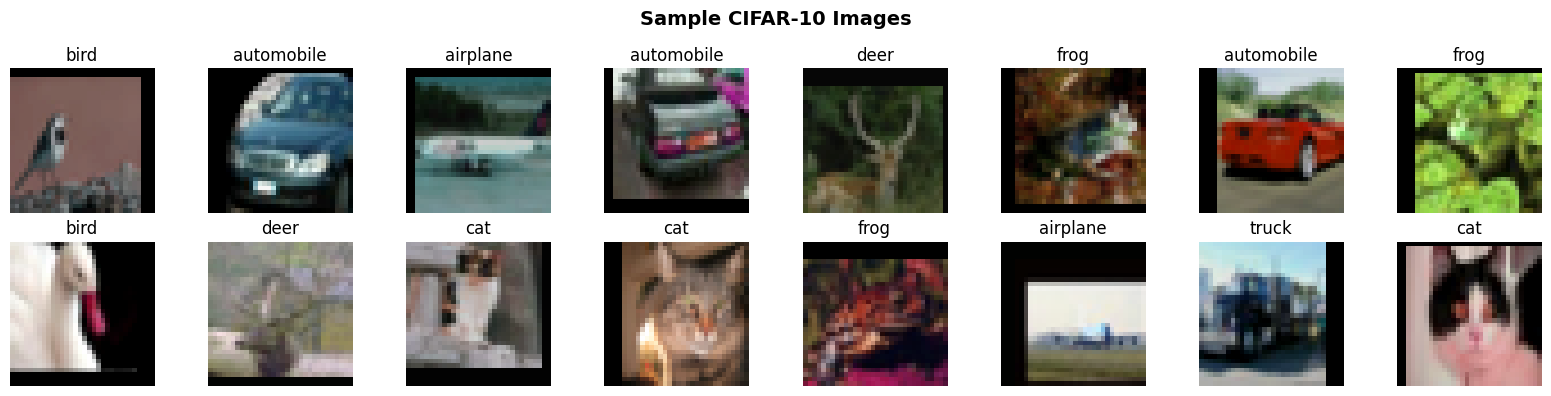

In [8]:
# visualizing
def imshow(img, title=None):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)
    imshow(images[i], title=CLASSES[labels[i]])
plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# spliting each 32×32 image into non-overlapping 4×4 patches, then linearly project each patch to EMBED_DIM
class PatchEmbedding(nn.Module):
    """Input : (B, C, H, W)
       Output: (B, num_patches, embed_dim"""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=512):
        super().__init__()
        self.img_size    = img_size
        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # A Conv2d with kernel_size=patch_size and stride=patch_size to do a non-overlapping patch projection in one step.
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.projection(x)          # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)                # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)           # (B, num_patches, embed_dim)
        return x

patch_embed = PatchEmbedding(IMG_SIZE, PATCH_SIZE, IN_CHANNELS, EMBED_DIM)
dummy = torch.randn(2, 3, 32, 32)
out = patch_embed(dummy)
#print(f'PatchEmbedding output shape: {out.shape}')

### Step 2: Multi-Head Self-Attention (MHSA)

In [11]:
class MultiHeadSelfAttention(nn.Module):
    """Input : (B, N, D)  — N tokens, D embed_dim
       Output: (B, N, D)"""
    def __init__(self, embed_dim=512, num_heads=8, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5    # 1/√d_k

        # single matrix for Q, K, V projection
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        # compute Q, K, V and split into heads
        qkv = self.qkv(x) #(B, N, 3*D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)           # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)                    # each: (B, heads, N, head_dim)

        # scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)

        # weighted sum of values
        x = (attn @ v)                              # (B, heads, N, head_dim)
        x = x.transpose(1, 2).reshape(B, N, D)     # (B, N, D)
        x = self.proj(x)
        return x

mhsa = MultiHeadSelfAttention(EMBED_DIM, NUM_HEADS)
dummy = torch.randn(2, NUM_PATCHES + 1, EMBED_DIM)  # +1 for CLS token
#print(f'MHSA output shape: {mhsa(dummy).shape}')

In [12]:
# two-layer feed-forward network with GELU activation
class MLPBlock(nn.Module):
    """ Input : (B, N, D)
        Output: (B, N, D)"""
    def __init__(self, embed_dim=512, mlp_dim=256, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim * 4),  # expand
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim * 4, embed_dim),  # contract
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [13]:
"""One Transformer encoder block: x → LayerNorm → MHSA → residual
                                    → LayerNorm → MLP  → residual"""
class TransformerEncoderBlock(nn.Module):
    """Input : (B, N, D)
       Output: (B, N, D)"""
    def __init__(self, embed_dim=512, num_heads=8, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = MLPBlock(embed_dim, mlp_dim, dropout)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        # Pre-norm (more stable for training from scratch)
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.mlp(self.norm2(x)))
        return x

In [15]:
class VisionTransformer(nn.Module):
    """Full ViT model for image classification.
    Pipeline:
      1. Patch Embedding
      2. Prepend [CLS] token
      3. Add learnable positional embeddings
      4. Pass through L Transformer Encoder blocks
      5. Extract [CLS] token representation
      6. MLP Classification head
    """
    def __init__(
        self,
        img_size    = 32,
        patch_size  = 4,
        in_channels = 3,
        num_classes = 10,
        embed_dim   = 512,
        depth       = 6,
        num_heads   = 8,
        mlp_dim     = 256,
        dropout     = 0.1,
    ):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        # 1.Patch Embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)

        # 2. CLS token (one learnable vector per batch)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # 3. Positional Embeddings
        #   +1 for the CLS token position
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # 4. Transformer Encoder
        self.transformer = nn.Sequential(*[
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(depth)
        ])

        # 5. Final LayerNorm
        self.norm = nn.LayerNorm(embed_dim)

        # 6. Classification Head
        self.head = nn.Linear(embed_dim, num_classes)

        # Weight initialisation
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]

        # patch embedding: (B, num_patches, embed_dim)
        x = self.patch_embed(x)

        # expanding CLS token for entire batch and prepending
        cls = self.cls_token.expand(B, -1, -1)     # (B, 1, embed_dim)
        x   = torch.cat([cls, x], dim=1)            # (B, num_patches+1, embed_dim)

        # adding positional embeddings
        x = self.pos_drop(x + self.pos_embed)

        # Transformer encoder
        x = self.transformer(x)
        x = self.norm(x)

        # CLS token (index 0) for classification
        cls_out = x[:, 0]                           # (B, embed_dim)
        return self.head(cls_out)                   # (B, num_classes)

model = VisionTransformer(
    img_size    = IMG_SIZE,
    patch_size  = PATCH_SIZE,
    in_channels = IN_CHANNELS,
    num_classes = NUM_CLASSES,
    embed_dim   = EMBED_DIM,
    depth       = DEPTH,
    num_heads   = NUM_HEADS,
    mlp_dim     = MLP_DIM,
    dropout     = DROPOUT,
).to(device)

#dummy = torch.randn(4, 3, 32, 32).to(device)
#out   = model(dummy)
#print(f'Output logits shape: {out.shape}')  # Expected: (4, 10)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters : 12,672,522
Trainable parameters: 12,672,522


In [16]:
!pip install -q torchinfo
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32), device=device,
        col_names=['input_size', 'output_size', 'num_params', 'trainable'])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
VisionTransformer                             [1, 3, 32, 32]            [1, 10]                   33,792                    True
├─PatchEmbedding: 1-1                         [1, 3, 32, 32]            [1, 64, 512]              --                        True
│    └─Conv2d: 2-1                            [1, 3, 32, 32]            [1, 512, 8, 8]            25,088                    True
├─Dropout: 1-2                                [1, 65, 512]              [1, 65, 512]              --                        --
├─Sequential: 1-3                             [1, 65, 512]              [1, 65, 512]              --                        True
│    └─TransformerEncoderBlock: 2-2           [1, 65, 512]              [1, 65, 512]              --                        True
│    │    └─LayerNorm: 3-1                    [1, 65, 512]              [1, 65, 512]          

In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

# Cosine annealing scheduler with linear warm-up
WARMUP_EPOCHS = 5
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Optimizer :', optimizer.__class__.__name__)
print('Scheduler :', scheduler.__class__.__name__)
print('Loss      :', criterion)

Optimizer : AdamW
Scheduler : LambdaLR
Loss      : CrossEntropyLoss()


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct+= (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

best_val_acc = 0.0

print(f"{'Epoch':>5} {'LR':>8} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9} {'Time':>6}")
print('─' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    elapsed = time.time()-t0
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'vit_best.pth')
        marker = ' saved'
    else:
        marker = ''

    print(f'{epoch:5d} {current_lr:8.6f} {train_loss:11.4f} {train_acc:10.4f} '
          f'{val_loss:10.4f} {val_acc:9.4f} {elapsed:5.1f}s{marker}')

print(f'\nBest Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

Epoch       LR  Train Loss  Train Acc   Val Loss   Val Acc   Time
─────────────────────────────────────────────────────────────────
    1 0.000400      1.7267     0.4252     1.6194    0.4874  97.7s saved
    2 0.000600      1.6667     0.4580     1.5722    0.5092  99.9s saved
    3 0.000800      1.6259     0.4787     1.5493    0.5073  97.8s
    4 0.001000      1.6299     0.4753     1.5589    0.5154  97.7s saved
    5 0.001000      1.6752     0.4546     1.7177    0.4315  97.9s
    6 0.000996      1.6814     0.4515     1.5860    0.5026  98.2s
    7 0.000984      1.6828     0.4505     1.6383    0.4742  98.4s
    8 0.000965      1.6803     0.4532     1.6304    0.4796  98.2s
    9 0.000938      1.6725     0.4559     1.6210    0.4859  98.1s
   10 0.000905      1.6908     0.4452     1.6097    0.4862  98.3s
   11 0.000864      1.6811     0.4516     1.5952    0.4955  98.2s
   12 0.000819      1.6733     0.4561     1.6247    0.4808  98.2s
   13 0.000768      1.6641     0.4609     1.5548    0.5128

In [20]:
# loading the best saved model
model.load_state_dict(torch.load('vit_best.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

Test Accuracy: 0.6152 (61.52%)


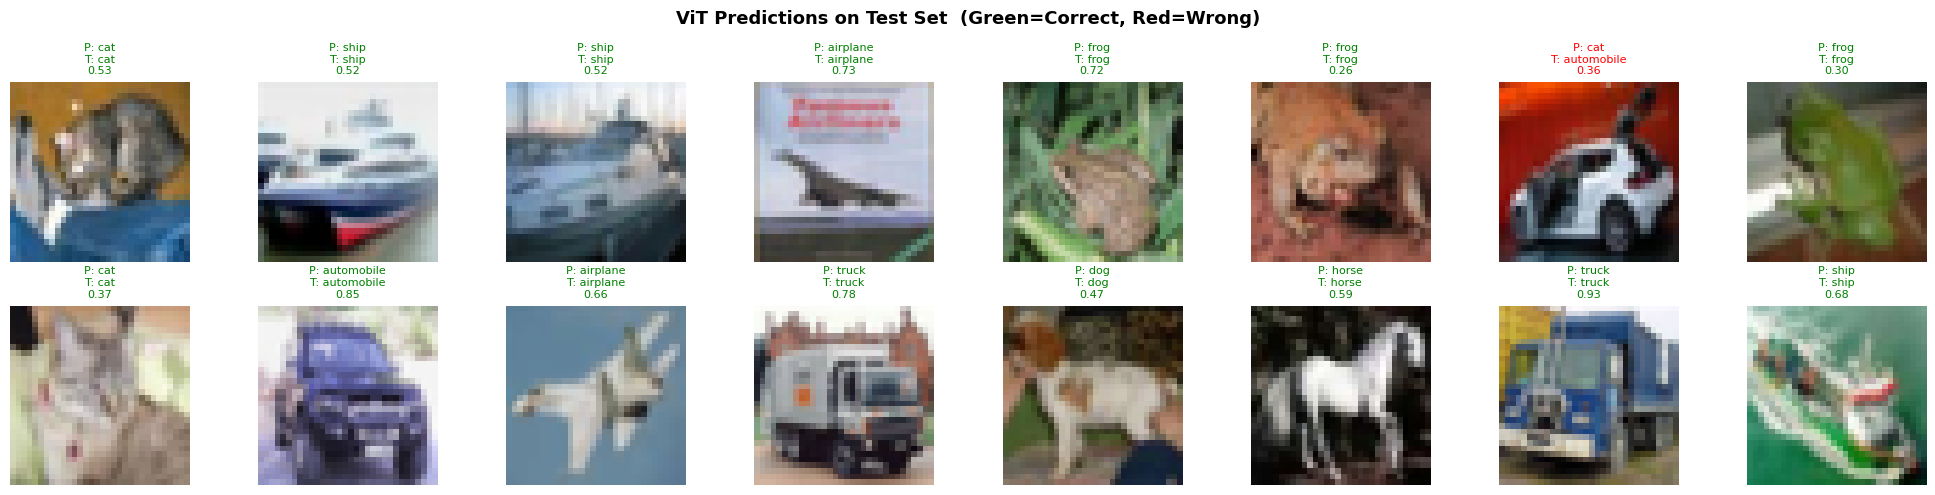

In [21]:
model.eval()
images, labels = next(iter(test_loader))
images_gpu = images[:16].to(device)

with torch.no_grad():
    logits = model(images_gpu)
    probs  = F.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1).cpu()
    confs  = probs.max(dim=1).values.cpu()

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)
    imshow(images[i])
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f'P: {CLASSES[preds[i]]}\nT: {CLASSES[labels[i]]}\n{confs[i]:.2f}',
                 color=color, fontsize=8)

plt.suptitle('ViT Predictions on Test Set  (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()